<a href="https://colab.research.google.com/github/np03cs4a240306-blip/Saurav-Sapkota/blob/main/workshop6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
def logistic_function(x):
    """
    Computes the logistic (sigmoid) function applied to any value of x.

    Arguments:
    x: scalar or numpy array of any size.

    Returns:
    y: logistic function applied to x.
    """
    import numpy as np
    y = 1 / (1 + np.exp(-x))
    return y


In [2]:
import numpy as np

print(logistic_function(0))          # scalar
print(logistic_function(np.array([0, 1, 2, -1])))


0.5
[0.5        0.73105858 0.88079708 0.26894142]


In [3]:
import numpy as np

def logistic_function(x):
    """
    Computes the logistic (sigmoid) function applied to any value of x.
    """
    return 1 / (1 + np.exp(-x))


def test_logistic_function():
    """
    Test cases for the logistic_function.
    """

    # Test with scalar input
    x_scalar = 0
    expected_output_scalar = round(1 / (1 + np.exp(0)), 3)  # 0.5
    assert round(logistic_function(x_scalar), 3) == expected_output_scalar, \
        "Test failed for scalar input"

    # Test with positive scalar input
    x_pos = 2
    expected_output_pos = round(1 / (1 + np.exp(-2)), 3)  # ~0.881
    assert round(logistic_function(x_pos), 3) == expected_output_pos, \
        "Test failed for positive scalar input"

    # Test with negative scalar input
    x_neg = -3
    expected_output_neg = round(1 / (1 + np.exp(3)), 3)  # ~0.047
    assert round(logistic_function(x_neg), 3) == expected_output_neg, \
        "Test failed for negative scalar input"

    # Test with numpy array input
    x_array = np.array([0, 2, -3])
    expected_output_array = np.array([0.5, 0.881, 0.047])

    assert np.all(np.round(logistic_function(x_array), 3) == expected_output_array), \
        "Test failed for numpy array input"

    print("All tests passed!")


# Run the test case
test_logistic_function()


All tests passed!


In [4]:
def log_loss(y_true, y_pred):
    """
    Computes log loss for true target value y ∈ {0,1}
    and predicted target value y_pred ∈ (0,1).
    """
    import numpy as np

    # Avoid log(0)
    y_pred = np.clip(y_pred, 1e-10, 1 - 1e-10)

    loss = -(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

    return loss


In [5]:
print(log_loss(1, 0.9))
print(log_loss(0, 0.2))


0.10536051565782628
0.2231435513142097


In [6]:
# Test function:
y_true, y_pred = 0, 0.1
print(f"log loss({y_true}, {y_pred}) ==> {log_loss(y_true, y_pred)}")

print("+++++++++++++--------------------------++++++++++++++++++++++++")

y_true, y_pred = 1, 0.9
print(f"log loss({y_true}, {y_pred}) ==> {log_loss(y_true, y_pred)}")


log loss(0, 0.1) ==> 0.10536051565782628
+++++++++++++--------------------------++++++++++++++++++++++++
log loss(1, 0.9) ==> 0.10536051565782628


In [7]:
def test_log_loss():
    """
    Test cases for the log_loss function.
    """
    import numpy as np

    # Test case 1: Perfect prediction (y_true = 1, y_pred = 1)
    y_true = 1
    y_pred = 1
    expected_loss = 0.0
    assert np.isclose(log_loss(y_true, y_pred), expected_loss), \
        "Test failed for perfect prediction (y_true=1, y_pred=1)"

    # Test case 2: Perfect prediction (y_true = 0, y_pred = 0)
    y_true = 0
    y_pred = 0
    expected_loss = 0.0
    assert np.isclose(log_loss(y_true, y_pred), expected_loss), \
        "Test failed for perfect prediction (y_true=0, y_pred=0)"

    # Test case 3: Incorrect prediction (y_true = 1, y_pred = 0)
    y_true = 1
    y_pred = 0
    loss = log_loss(y_true, y_pred)
    assert loss > 0, "Test failed for incorrect prediction (y_true=1, y_pred=0)"

    # Test case 4: Incorrect prediction (y_true = 0, y_pred = 1)
    y_true = 0
    y_pred = 1
    loss = log_loss(y_true, y_pred)
    assert loss > 0, "Test failed for incorrect prediction (y_true=0, y_pred=1)"

    # Test case 5: Partially correct prediction
    y_true = 1
    y_pred = 0.8
    expected_loss = -np.log(0.8)
    assert np.isclose(log_loss(y_true, y_pred), expected_loss, atol=1e-6), \
        "Test failed for partially correct prediction (y_true=1, y_pred=0.8)"

    y_true = 0
    y_pred = 0.2
    expected_loss = -np.log(0.8)
    assert np.isclose(log_loss(y_true, y_pred), expected_loss, atol=1e-6), \
        "Test failed for partially correct prediction (y_true=0, y_pred=0.2)"

    print("All tests passed!")


In [8]:
test_log_loss()


All tests passed!


In [9]:
def cost_function(y_true, y_pred):
    """
    Computes log loss for inputs true value (0 or 1) and predicted value (between 0 and 1)
    """
    import numpy as np

    assert len(y_true) == len(y_pred), \
        "Length of true values and length of predicted values do not match"

    # number of samples
    n = len(y_true)

    # avoid log(0)
    y_pred = np.clip(y_pred, 1e-10, 1 - 1e-10)

    # vector of losses
    loss_vec = -(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

    # average cost
    cost = np.sum(loss_vec) / n

    return cost


In [10]:
import numpy as np

y_true = np.array([1, 0, 1, 0])
y_pred = np.array([0.9, 0.2, 0.8, 0.1])

print(cost_function(y_true, y_pred))


0.16425203348601802


In [11]:
import numpy as np

def test_cost_function():
    # Test case 1: Simple example with known expected cost
    y_true = np.array([1, 0, 1])
    y_pred = np.array([0.9, 0.1, 0.8])

    # Manually computed expected cost
    expected_cost = (
        -np.log(0.9)
        -np.log(1 - 0.1)
        -np.log(0.8)
    ) / 3

    # Call the cost_function
    result = cost_function(y_true, y_pred)

    # Check result
    assert np.isclose(result, expected_cost, atol=1e-6), \
        f"Test failed: {result} != {expected_cost}"

    print("Test passed for simple case!")

# Run the test
test_cost_function()


Test passed for simple case!


In [12]:
import numpy as np

# Sigmoid function
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Vectorized cost function for logistic regression
def costfunction_logreg(X, y, w, b):
    """
    Computes the cost function, given data and model parameters.

    Args:
    X (ndarray, shape (m,n)): data on features, m observations with n features.
    y (array_like, shape (m,)): array of true values of target (0 or 1).
    w (array_like, shape (n,)): weight parameters of the model.
    b (float): bias parameter of the model.

    Returns:
    cost (float): nonnegative cost corresponding to y and y_pred.
    """
    m, n = X.shape
    assert len(y) == m, "Number of feature observations and number of target observations do not match."
    assert len(w) == n, "Number of features and number of weight parameters do not match."

    # Compute z = X.w + b
    z = np.dot(X, w) + b

    # Compute predictions using logistic function
    y_pred = sigmoid(z)

    # Compute the cost using previously defined cost_function
    cost = cost_function(y, y_pred)

    return cost


In [13]:
X = np.array([[10, 20], [-10, 10]])
y = np.array([1, 0])
w = np.array([0.5, 1.5])
b = 1

print(f"cost for logistic regression(X = {X}, y = {y}, w = {w}, b = {b}) = {costfunction_logreg(X, y, w, b)}")

cost for logistic regression(X = [[ 10  20]
 [-10  10]], y = [1 0], w = [0.5 1.5], b = 1) = 5.500008350834906


In [14]:
import numpy as np

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def compute_gradient(X, y, w, b):
    """
    Computes gradients of the cost function with respect to model parameters.

    Args:
    X (ndarray, shape (n,d)): Input data, n observations with d features
    y (array_like, shape (n,)): True labels (0 or 1)
    w (array_like, shape (d,)): Weight parameters of the model
    b (float): Bias parameter of the model

    Returns:
    grad_w (array_like, shape (d,)): Gradients w.r.t weights
    grad_b (float): Gradient w.r.t bias
    """
    n, d = X.shape
    assert len(y) == n, f"Expected y to have {n} elements, but got {len(y)}"
    assert len(w) == d, f"Expected w to have {d} elements, but got {len(w)}"

    # Compute predictions
    z = np.dot(X, w) + b
    y_pred = sigmoid(z)

    # Compute gradients
    error = y_pred - y                  # shape (n,)
    grad_w = np.dot(X.T, error) / n     # shape (d,)
    grad_b = np.sum(error) / n          # scalar

    return grad_w, grad_b


In [15]:
X = np.array([[1, 2], [3, 4]])
y = np.array([0, 1])
w = np.array([0.1, 0.2])
b = 0.5

grad_w, grad_b = compute_gradient(X, y, w, b)
print("Gradient w.r.t w:", grad_w)
print("Gradient w.r.t b:", grad_b)


Gradient w.r.t w: [0.11355687 0.39509535]
Gradient w.r.t b: 0.2815384818819647


In [16]:
import numpy as np

# Simple test case
X = np.array([[10, 20], [-10, 10]])  # shape (2, 2)
y = np.array([1, 0])                  # shape (2,)
w = np.array([0.5, 1.5])              # shape (2,)
b = 1                                  # scalar

# Assertion tests
try:
    grad_w, grad_b = compute_gradient(X, y, w, b)
    print("Gradients computed successfully.")
    print(f"grad_w: {grad_w}")
    print(f"grad_b: {grad_b}")
except AssertionError as e:
    print(f"Assertion error: {e}")


Gradients computed successfully.
grad_w: [-4.99991649  4.99991649]
grad_b: 0.4999916492890759


In [20]:
import numpy as np

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def cost_function(y_true, y_pred):
    y_pred = np.clip(y_pred, 1e-10, 1 - 1e-10)
    loss_vec = -(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))
    return np.mean(loss_vec)

def compute_gradient(X, y, w, b):
    n, d = X.shape
    z = np.dot(X, w) + b
    y_pred = sigmoid(z)
    error = y_pred - y
    grad_w = np.dot(X.T, error) / n
    grad_b = np.sum(error) / n
    return grad_w, grad_b

def gradient_descent(X, y, w, b, alpha, n_iter, show_cost=False, show_params=True):
    """
    Implements batch gradient descent to optimize logistic regression parameters.
    """
    n, d = X.shape
    assert len(y) == n, "Number of observations in X and y do not match"
    assert len(w) == d, "Number of features in X and w do not match"

    cost_history = []
    params_history = []

    for i in range(n_iter):

        grad_w, grad_b = compute_gradient(X, y, w, b)
        w -= alpha * grad_w
        b -= alpha * grad_b
        z = np.dot(X, w) + b
        y_pred = sigmoid(z)
        cost = cost_function(y, y_pred)
        cost_history.append(cost)
        params_history.append((w.copy(), b))
        if show_cost and (i % 100 == 0 or i == n_iter - 1):
            print(f"Iteration {i}: Cost = {cost:.6f}")
        if show_params and (i % 100 == 0 or i == n_iter - 1):
            print(f"Iteration {i}: w = {w}, b = {b:.6f}")

    return w, b, cost_history, params_history


In [19]:

X = np.array([[0.1, 0.2], [-0.1, 0.1]])
y = np.array([1, 0])
w = np.zeros(X.shape[1])
b = 0.0
alpha = 0.1
n_iter = 1000

w_out, b_out, cost_history, params_history = gradient_descent(
    X, y, w, b, alpha, n_iter, show_cost=True, show_params=False
)
print("\nFinal parameters:")
print(f"w: {w_out}, b: {b_out}")
print(f"Final cost: {cost_history[-1]:.6f}")


Iteration 0: Cost = 0.692835
Iteration 100: Cost = 0.662662
Iteration 200: Cost = 0.634332
Iteration 300: Cost = 0.607704
Iteration 400: Cost = 0.582671
Iteration 500: Cost = 0.559128
Iteration 600: Cost = 0.536977
Iteration 700: Cost = 0.516126
Iteration 800: Cost = 0.496487
Iteration 900: Cost = 0.477978
Iteration 999: Cost = 0.460693

Final parameters:
w: [4.30539485 2.10704574], b: -0.30434456824754946
Final cost: 0.460693


In [22]:
import numpy as np

def test_gradient_descent():
    X = np.array([[0.1, 0.2], [-0.1, 0.1]])
    y = np.array([1, 0])
    w = np.zeros(X.shape[1])
    b = 0.0
    alpha = 0.1
    n_iter = 100

    # Run gradient descent
    w_out, b_out, cost_history, _ = gradient_descent(
        X, y, w, b, alpha, n_iter, show_cost=False, show_params=False
    )

    # Assertions
    assert len(cost_history) == n_iter, "Cost history length does not match the number of iterations"
    assert w_out.shape == w.shape, "Shape of output weights does not match the initial weights"
    assert isinstance(b_out, float), "Bias output is not a float"
    assert cost_history[-1] < cost_history[0], "Cost did not decrease over iterations"

    print("All tests passed!")

# Run the test
test_gradient_descent()


All tests passed!


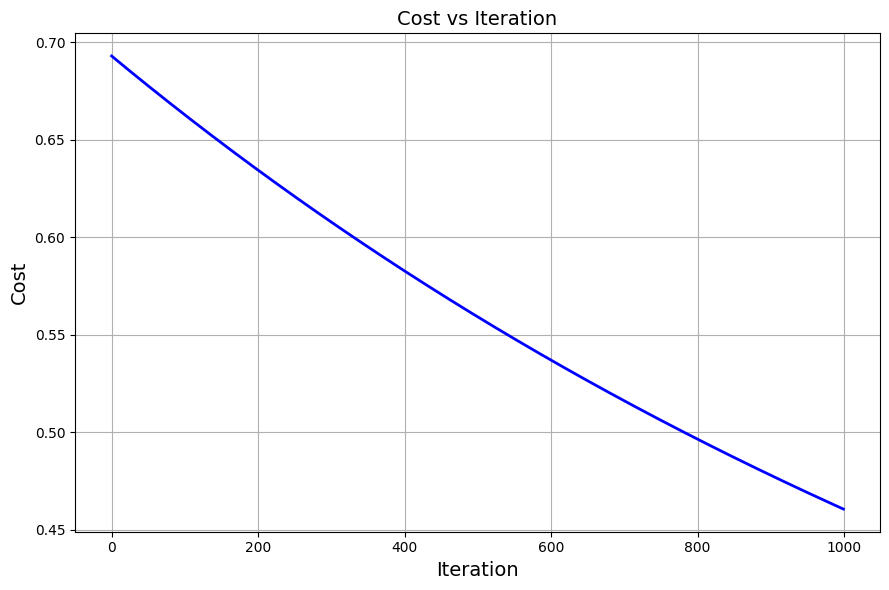

In [23]:
import matplotlib.pyplot as plt

# Assuming cost_history is from your gradient_descent run
plt.figure(figsize=(9, 6))
plt.plot(cost_history, color='blue', linewidth=2)
plt.xlabel("Iteration", fontsize=14)
plt.ylabel("Cost", fontsize=14)
plt.title("Cost vs Iteration", fontsize=14)
plt.grid(True)
plt.tight_layout()
plt.show()


In [24]:
import numpy as np

def prediction(X, w, b, threshold=0.5):
    z = np.dot(X, w) + b
    y_test_prob = 1 / (1 + np.exp(-z))
    y_pred = (y_test_prob >= threshold).astype(int)
    return y_pred


In [25]:
X_test = np.array([[0.1, 0.2], [-0.1, 0.1]])
w = np.array([0.3, 0.5])
b = -0.1

y_pred = prediction(X_test, w, b)
print(y_pred)


[1 0]


In [26]:
import numpy as np

def test_prediction():
    X_test = np.array([[0.5, 1.0], [1.5, -0.5], [-0.5, -1.0]])  # Shape (3, 2)
    w_test = np.array([1.0, -1.0])                                # Shape (2,)
    b_test = 0.0                                                   # Scalar bias
    threshold = 0.5                                                # Default threshold

    # Expected output
    expected_output = np.array([0, 1, 1])

    # Call the prediction function
    y_pred = prediction(X_test, w_test, b_test, threshold)

    # Assert that the output matches the expected output
    assert np.array_equal(y_pred, expected_output), f"Expected {expected_output}, but got {y_pred}"

    print("Test passed!")

# Run the test
test_prediction()


Test passed!


In [27]:
import numpy as np

def evaluate_classification(y_true, y_pred):
    """
    Computes the confusion matrix, precision, recall, and F1-score for binary classification.
    """
    TP = np.sum((y_true == 1) & (y_pred == 1))
    TN = np.sum((y_true == 0) & (y_pred == 0))
    FP = np.sum((y_true == 0) & (y_pred == 1))
    FN = np.sum((y_true == 1) & (y_pred == 0))

    confusion_matrix = np.array([[TN, FP],
                                 [FN, TP]])

    precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0

    metrics = {
        "confusion_matrix": confusion_matrix,
        "precision": precision,
        "recall": recall,
        "f1_score": f1_score
    }
    return metrics


In [28]:
y_true = np.array([1, 0, 1, 0, 1])
y_pred = np.array([1, 0, 0, 0, 1])

metrics = evaluate_classification(y_true, y_pred)
print(metrics)


{'confusion_matrix': array([[2, 0],
       [1, 2]]), 'precision': np.float64(1.0), 'recall': np.float64(0.6666666666666666), 'f1_score': np.float64(0.8)}


In [29]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
columns = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
           'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

data_pima_diabetes = pd.read_csv(url, names=columns)
print(data_pima_diabetes.head())


   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


In [30]:
import numpy as np
import pandas as pd

# Columns to clean
columns_to_clean = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

# Replace 0 with NaN in these columns
data_pima_diabetes[columns_to_clean] = data_pima_diabetes[columns_to_clean].replace(0, np.nan)

# Fill NaN with median values
data_pima_diabetes.fillna(data_pima_diabetes.median(), inplace=True)

# Check data info
data_pima_diabetes.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    float64
 2   BloodPressure             768 non-null    float64
 3   SkinThickness             768 non-null    float64
 4   Insulin                   768 non-null    float64
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(6), int64(3)
memory usage: 54.1 KB


In [31]:
data_pima_diabetes.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.656250,72.386719,29.108073,140.671875,32.455208,0.471876,33.240885,0.348958
std,3.369578,30.438286,12.096642,8.791221,86.383060,6.875177,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,121.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,29.000000,125.000000,32.300000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [32]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Train-test split
X = data_pima_diabetes.drop(columns=['Outcome']).values
y = data_pima_diabetes['Outcome'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



Training Logistic Regression Model:
Iteration 0: Cost = 0.676575
Iteration 100: Cost = 0.465441
Iteration 200: Cost = 0.455913
Iteration 300: Cost = 0.453874
Iteration 400: Cost = 0.453316
Iteration 500: Cost = 0.453148
Iteration 600: Cost = 0.453096
Iteration 700: Cost = 0.453079
Iteration 800: Cost = 0.453074
Iteration 900: Cost = 0.453072
Iteration 999: Cost = 0.453071


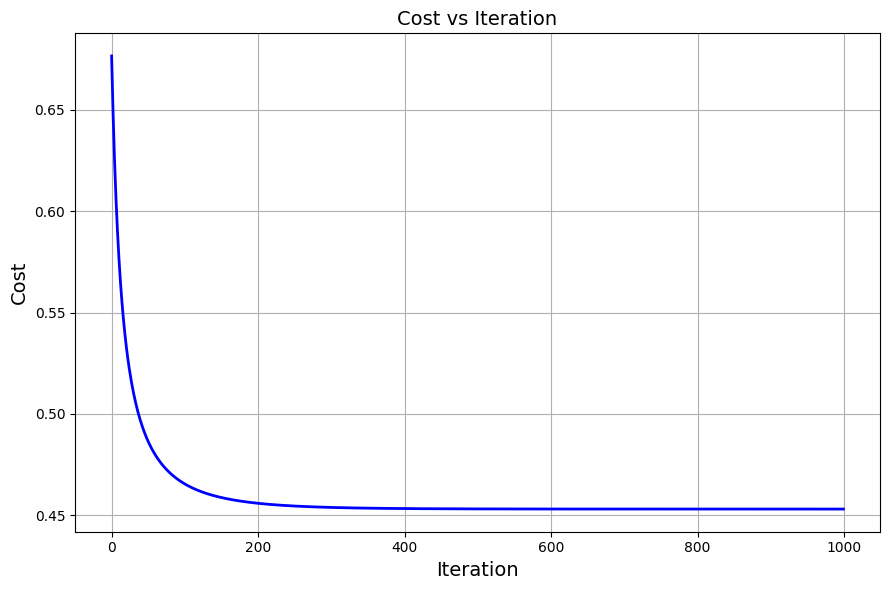

In [33]:
import matplotlib.pyplot as plt
import numpy as np

# Initialize parameters
w = np.zeros(X_train_scaled.shape[1])
b = 0.0
alpha = 0.1
n_iter = 1000

# Train model
print("\nTraining Logistic Regression Model:")
w, b, cost_history, params_history = gradient_descent(
    X_train_scaled, y_train, w, b, alpha, n_iter, show_cost=True, show_params=False
)

# Plot cost history
plt.figure(figsize=(9, 6))
plt.plot(cost_history, color='blue', linewidth=2)
plt.xlabel("Iteration", fontsize=14)
plt.ylabel("Cost", fontsize=14)
plt.title("Cost vs Iteration", fontsize=14)
plt.grid(True)
plt.tight_layout()
plt.show()


In [34]:
# Predict on train and test sets
y_train_pred = prediction(X_train_scaled, w, b)
y_test_pred = prediction(X_test_scaled, w, b)

# Evaluate train and test performance (cost)
train_cost = costfunction_logreg(X_train_scaled, y_train, w, b)
test_cost = costfunction_logreg(X_test_scaled, y_test, w, b)

print(f"\nTrain Loss (Cost): {train_cost:.4f}")
print(f"Test Loss (Cost): {test_cost:.4f}")



Train Loss (Cost): 0.4531
Test Loss (Cost): 0.5146



Test Accuracy: 70.78%

Confusion Matrix:
[[82 18]
 [27 27]]
Precision: 0.60
Recall: 0.50
F1-Score: 0.55


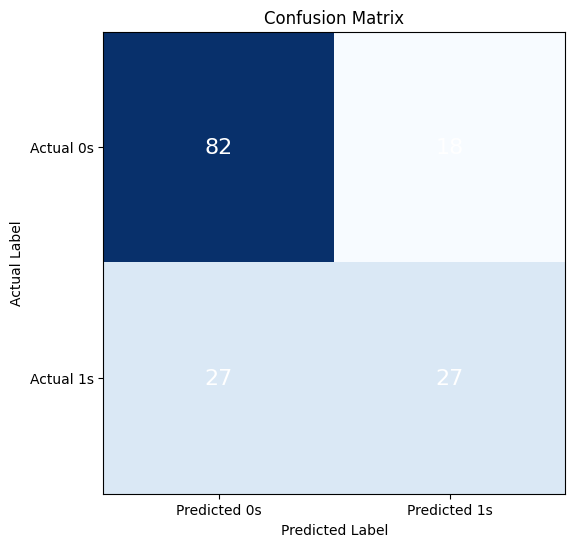

In [35]:
import matplotlib.pyplot as plt
import numpy as np

# Accuracy on test data
test_accuracy = np.mean(y_test_pred == y_test) * 100
print(f"\nTest Accuracy: {test_accuracy:.2f}%")

# Evaluation
metrics = evaluate_classification(y_test, y_test_pred)
confusion_matrix = metrics["confusion_matrix"]
precision = metrics["precision"]
recall = metrics["recall"]
f1_score = metrics["f1_score"]

print(f"\nConfusion Matrix:\n{confusion_matrix}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-Score: {f1_score:.2f}")

# Optional - Visualizing the Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(confusion_matrix, cmap='Blues')
ax.grid(False)

ax.xaxis.set(ticks=(0, 1), ticklabels=('Predicted 0s', 'Predicted 1s'))
ax.yaxis.set(ticks=(0, 1), ticklabels=('Actual 0s', 'Actual 1s'))
ax.set_ylim(1.5, -0.5)

for i in range(2):
    for j in range(2):
        ax.text(j, i, confusion_matrix[i, j], ha='center', va='center', color='white', fontsize=16)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix")
plt.show()
